0     10609.2
1     20067.6
2     32047.7
3     59859.3
4    125363.0
5    643637.0
Name: throughput_txn_per_sec, dtype: float64
0     7854.73
1     9810.73
2    10927.50
3    12769.10
4    12381.70
5    11636.70
Name: throughput_txn_per_sec, dtype: float64


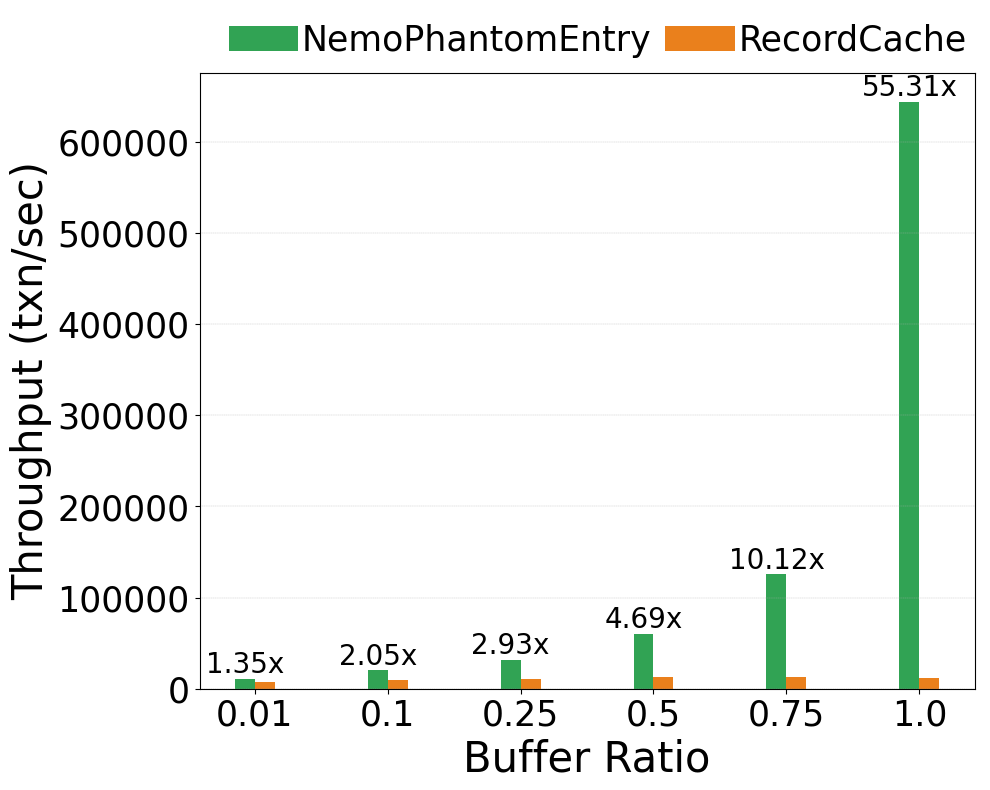

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
zipf_theta=0.9
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoPhantomEntry"
nemo_record_evict_label = "RecordCache"

datadir = "../../output/negative_search/"
exp_tuple_batch_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative1"
exp_tuple_record_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative0"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == zipf_theta]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] ==  zipf_theta]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset/2 , df_tuple_batch["throughput_txn_per_sec"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, df_tuple_record["throughput_txn_per_sec"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

speedup = ((df_tuple_batch["throughput_txn_per_sec"] / 
           df_tuple_record["throughput_txn_per_sec"] ) )

print(df_tuple_batch["throughput_txn_per_sec"])
print(df_tuple_record["throughput_txn_per_sec"])
for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)
ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


# ax1.set_xticks(indices)
# x_tick_num = np.round(df_tuple_batch[x_dimension] * 100 / (12 * 1000 * 1000 * 1000), 2).astype(int)
# x_tick_labels = [f"{num}%" for num in x_tick_num]

# ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)


# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
# ax1.set_ylim(0, 120000)
# ax1.set_ylim(0, 50000)

ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




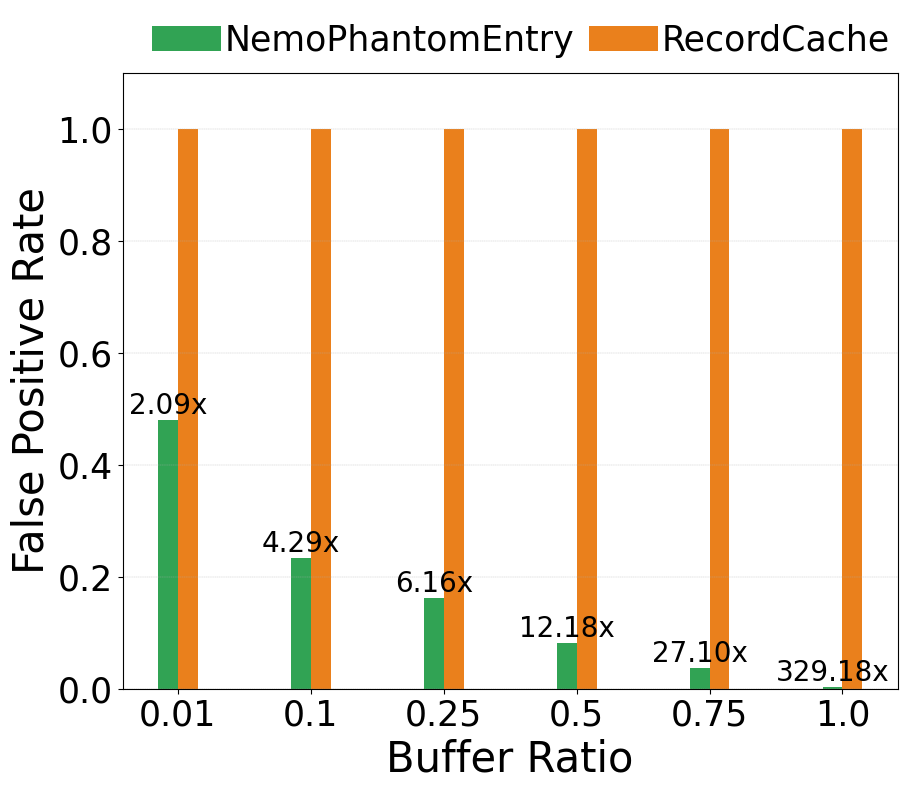

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25


x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoPhantomEntry"
nemo_record_evict_label = "RecordCache"
zipf_theta = 0.9
datadir = "../../output/negative_search/"
exp_tuple_batch_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative1"
exp_tuple_record_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative0"

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == zipf_theta]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == zipf_theta]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

batch_false_positive_rate = df_tuple_batch["false_positive_"]/(df_tuple_batch["false_positive_"] + df_tuple_batch["true_negative_"]) 
record_false_positive_rate = df_tuple_record["false_positive_"]/(df_tuple_record["false_positive_"] + df_tuple_record["true_negative_"])
fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
# print(df_tuple_batch["tuple_hit_rate_"])
# print(1- df_tuple_batch["tuple_hit_rate_"])
batch_bars = ax1.bar(indices - offset/2 , batch_false_positive_rate, bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, record_false_positive_rate, bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

speedup = (record_false_positive_rate / 
           batch_false_positive_rate )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 1.1)

ax1.set_ylabel("False Positive Rate", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
# ax1.set_xlabel("Record Size", fontsize=ticksize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




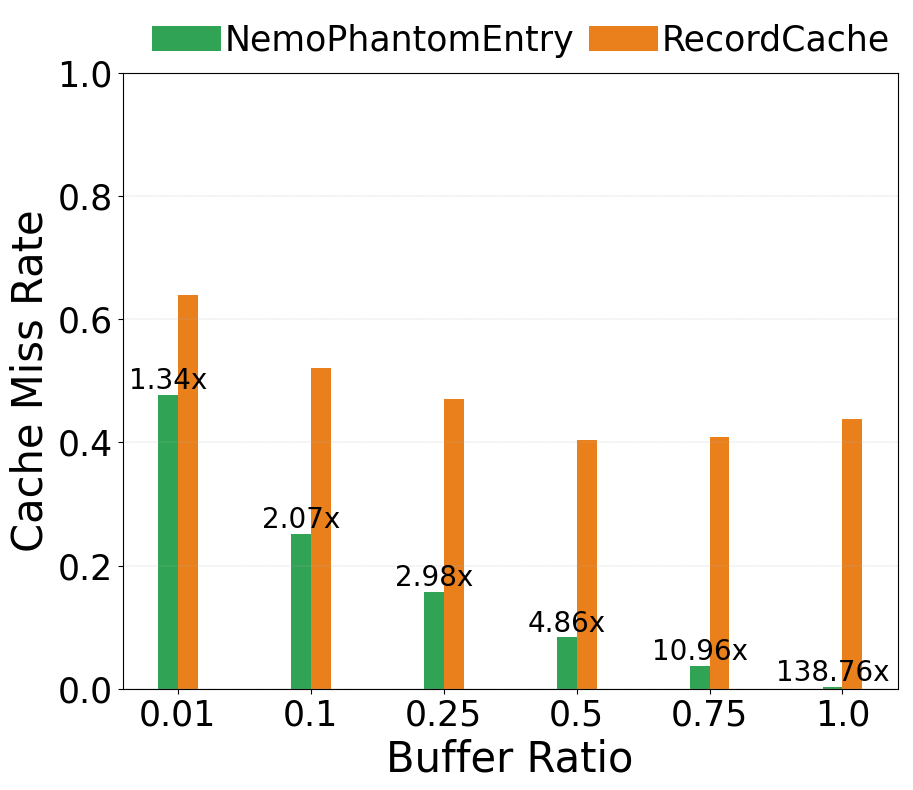

In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
zipf_theta = 0.9
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c =  "#ea801c"
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

x_dimension = "g_total_buf_sz"
nemo_batch_evict_label = "NemoPhantomEntry"
nemo_record_evict_label = "RecordCache"

datadir = "../../output/negative_search/"
exp_tuple_batch_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative1"
exp_tuple_record_evict = "exp_negative_search_point_varybuf_skew-zipf0.9-negative0"


data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == zipf_theta]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == zipf_theta]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)



fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(data_tuple_batch))
offset = bar_width

# Bar chart for the primary data
# print(df_tuple_batch["tuple_hit_rate_"])
# print(1- df_tuple_batch["tuple_hit_rate_"])
batch_bars = ax1.bar(indices - offset/2 , 1- df_tuple_batch["tuple_hit_rate_"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c)
record_bars = ax1.bar(indices + offset/2, 1- df_tuple_record["tuple_hit_rate_"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c)

speedup = (((1-df_tuple_record["tuple_hit_rate_"]) / 
           (1-df_tuple_batch["tuple_hit_rate_"]) ) )


for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'{gain:.2f}x',
            ha='center', va='bottom',
            fontsize=ticksize-5)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 1)

ax1.set_ylabel("Cache Miss Rate", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
# ax1.set_xlabel("Record Size", fontsize=ticksize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')


